# Comparing the splitstep and plane-wave methods

**What you'll learn:**
- How to run a split-step (real-space lattice) simulation of a full interferometer sequence
- How to compare split-step results against the plane-wave (Bloch) method
- How momentum width affects the agreement between the two approaches

I've seen that as I make the wavefunction narrower in momentum space the splitstep simulation moves towards the plane wave simulation.

I will investigate this effect in more detail by simulating an ensemble of atoms with the plane wave simulation that have a momentum spread equivalent to the wavefunction width in the splitstep simulation.

Lets start with the splitstep simulation:

In [1]:
import numpy as np
from mwave.integrate import make_kvec, make_phi
from matplotlib import pyplot as plt
from mwave.integrate.xintegrate import splitstep, x_to_kvec, kvec_to_x, xspace_to_pspace, make_continuous_phi, pspace_to_xspace
from numba import jit

# Define fixed parameters
n_init = 0
n_bragg = 4
omega = 19.4
sigma = 0.259
tau_factor = 3
T = 10
Tp = 5
target_phase = 0*np.pi/2
mod_phase = 0

# Compute dependent parameters
delta = 4*n_bragg
t_bragg = 2*tau_factor*sigma
t_spacing = T - t_bragg
tp_spacing = Tp - t_bragg
omega_m = 8*n_bragg-target_phase/(2*T*n_bragg)

tseg0 = 0
tseg1 = t_bragg
tseg2 = 2*t_bragg + t_spacing
tseg3 = 3*t_bragg + t_spacing + tp_spacing
tseg4 = 4*t_bragg + 2*t_spacing + tp_spacing

# Define kvec
kvec, n0_idx, nf_idx = make_kvec(n_init, n_init + n_bragg)

# Make splitstep parameters
klaser = np.sqrt(2)
xsig = 15
xextentneg = 1.2*(T+2*t_bragg)*-n_bragg*2*klaser
xextentpos = 1.2*((T+2*t_bragg+T)*n_bragg*2*klaser + (2*t_bragg+T)*2*n_bragg*2*klaser)
xvec = np.arange(xextentneg,xextentpos,0.1)
psi0 = np.exp(-np.square(xvec)/(2*xsig**2))/np.sqrt(xsig*np.sqrt(np.pi))*np.exp(1j*n_init*2*klaser*xvec)
ckvec = np.fft.fftfreq(len(xspace_to_pspace(psi0)), np.diff(xvec)[0])*2*np.pi/klaser

# Compute with splitstep
@jit(nopython=True)
def OmegaProfile(t):
    if t < tseg1: # Bragg 1
        return omega*np.exp(-np.square(t-(tseg1-t_bragg/2))/(2*np.square(sigma)))
    elif t < tseg2 - t_bragg:
        return 0.0
    elif t < tseg2: # Bragg 2
        return omega*np.exp(-np.square(t-(tseg2-t_bragg/2))/(2*np.square(sigma)))
    elif t < tseg3 - t_bragg:
        return 0.0
    elif t < tseg3: # Bragg 3
        return 2*np.cos(omega_m*(t-tseg3-t_bragg) + mod_phase)*omega*np.exp(-np.square(t-(tseg3-t_bragg/2))/(2*np.square(sigma)))
    elif t < tseg4 - t_bragg:
        return 0.0
    elif t < tseg4: # Bragg 4
        return 2*np.cos(omega_m*(t-tseg3-t_bragg) + mod_phase)*omega*np.exp(-np.square(t-(tseg4-t_bragg/2))/(2*np.square(sigma)))
    else:
        return 0.0

# Set x grid, potential, and phi0
@jit(nopython=True)
def Vfnc(t):
    return OmegaProfile(t)*2*(np.square(np.cos(klaser*xvec-delta*t/2)) - 0.5) # minus 0.5 to remove AC stark shift

psi1 = splitstep(xvec, tseg1, 0.0005, Vfnc, np.copy(psi0), klaser, tstart=tseg0, store_hist=False)
psi2 = splitstep(xvec, tseg2, 0.0005, Vfnc, psi1, klaser, tstart=tseg1, store_hist=False)
psi3 = splitstep(xvec, tseg3, 0.0005, Vfnc, psi2, klaser, tstart=tseg2, store_hist=False)
psi4 = splitstep(xvec, tseg4, 0.0005, Vfnc, psi3, klaser, tstart=tseg3, store_hist=False)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19999/19999 [00:17<00:00, 1137.69it/s]


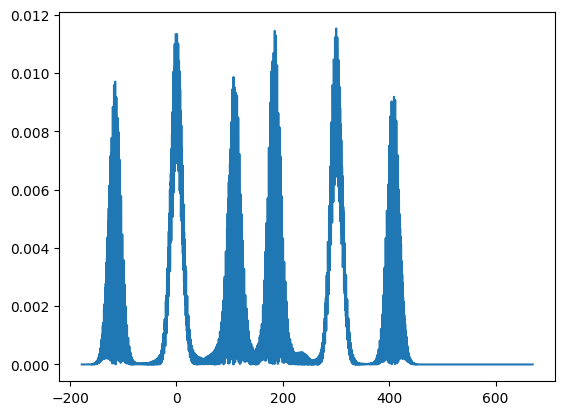

In [2]:
plt.plot(xvec, np.abs(psi4)**2)
plt.show()

In [3]:
phi = xspace_to_pspace(psi4)

shifted_ckvec = np.fft.fftshift(ckvec)
cpops = np.zeros_like(kvec, dtype=float)
pops = np.fft.fftshift(np.abs(phi)**2)

for i in range(len(kvec)):
    i0 = np.argmin(np.abs(shifted_ckvec - (kvec[i] - 1)))
    i1 = np.argmin(np.abs(shifted_ckvec - (kvec[i] + 1)))

    cpops[i] = np.trapz(pops[i0:i1], shifted_ckvec[i0:i1])

cpops /= np.sum(cpops)

state2idx = lambda nstate: np.argmin(np.abs(kvec - 2*nstate))
arridx = np.array([state2idx(2*n_bragg), state2idx(n_bragg), state2idx(0), state2idx(-n_bragg)])

pA, pB, pC, pD = cpops[arridx]
pA, pB, pC, pD

/var/folders/d7/6t4hylss1p9_9vftvfm4fbm80000gn/T/ipykernel_41528/630846714.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  cpops[i] = np.trapz(pops[i0:i1], shifted_ckvec[i0:i1])


(np.float64(0.3613023794837458),
 np.float64(0.12050147253410211),
 np.float64(0.3599777025771895),
 np.float64(0.12058717738992883))

I will copy these values to a cell below for comparison with the planewave method!

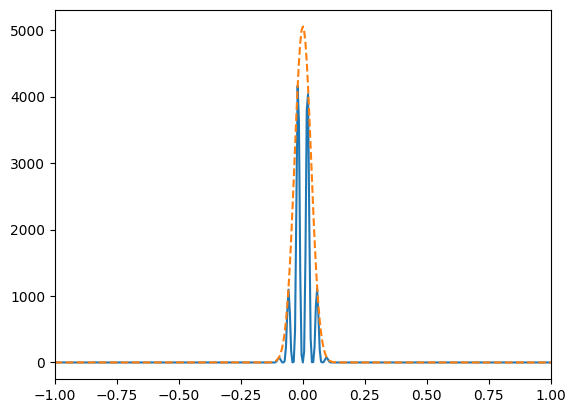

In [4]:
plt.plot(shifted_ckvec, np.fft.fftshift(np.abs(phi)**2))
psig = 1/xsig/klaser
phi_analytic = np.exp(-np.square(shifted_ckvec)/(2*psig**2))
plt.plot(shifted_ckvec, np.max(np.abs(phi)**2)*np.square(phi_analytic), linestyle='--') # Factor of 4 
plt.xlim([-1,1])
plt.show()

### Simulating a distribution of momenta to recover the splitstep result

Now I want to perform the planewave simulation at several different detuning values to see if I can get agreement with the splitstep method.

In [5]:
import numpy as np
from mwave.integrate import make_kvec, make_phi
from mwave.numeric import NumericBraggInterferometer
from scipy.integrate import solve_ivp
import numpy as np
from numba import jit, float64

# Set interferometer parameters
nbragg = 4
T = 10
Tp = 5
    
# Initialize kvec and tree
ifr = NumericBraggInterferometer(-2*nbragg, 4*nbragg, distance=4) # Should pass in wavefunction initialization functions

ifr.split(nbragg) # Should pass in the relevant function here as well! Function will inspect input function arguments to ensure correct number and naming
ifr.propagate(T)
ifr.split(nbragg)
ifr.propagate(Tp)
ifr.split([3*nbragg, -nbragg])
ifr.propagate(T)
ifr.split([3*nbragg, -nbragg])

We define a batched Bragg propagator built on top of :py:func:`mwave.integrate.propagate`. Instead of looping over detunings and calling ``solve_ivp`` once per atom, we hand the whole batch to ``propagate`` in one shot.

The Bragg pulse for atom :math:`i` needs the laser phase :math:`\delta_i t` (the laser drive phase already accumulated by the absolute pulse start time :math:`t`). Per-atom phase offsets are not directly supported by ``propagate``'s shared ``phase`` callable, so we absorb them via a change of frame: define :math:`\psi_i[j] = e^{i\delta_i t \cdot j}\,\phi_i[j]`, where :math:`j` is the momentum-grid index. The transformed wavefunction satisfies the standard equation with ``phase=0``. After integration we recover :math:`\phi_i[j] = e^{-i\delta_i t \cdot j}\,\psi_i[j]`. This is exact (no global-phase ambiguity), and reduces the wall-clock cost of each beamsplitter from ``len(deltas)`` scipy calls to a single batched ``propagate`` call.

In [6]:
from numba import jit, float64
import mwave.integrate as mi
from mwave.integrate import omega_fnc_gaussian, phase_fnc_constant, make_phi

@jit(float64(float64, float64[:]))
def multi_omega_fnc(t, args):
    omega, sigma, t0, mod_freq, mod_phase = args
    return 2*np.cos(mod_freq*t + mod_phase)*omega*np.exp(-np.square(t-t0)/(2*(sigma**2)))

def gbragg_batched(kvec, phi0_single, tfinal, deltas, omega, sigma, t_off,
                   dphase=0.0, omega_mod=None, mod_phase=0.0,
                   atol=1e-10, rtol=1e-10, tol=1e-10):
    """Batched Bragg propagator across many detunings.

    The Hamiltonian seen by atom ``i`` has detuning ``deltas[i]`` and a
    constant laser phase ``deltas[i] * t_off + dphase``. We absorb the per-atom
    constant phase via a momentum-grid phase ramp before/after integration so
    that the underlying call to :py:func:`mwave.integrate.propagate` only needs
    a shared ``dphase``.
    """
    deltas = np.asarray(deltas, dtype=np.float64)
    natoms = len(deltas)

    # Frame phase: V[i, j] = exp(i * delta_i * t_off * j) where j is grid index
    j_idx = np.arange(len(kvec))
    frame_phase = np.exp(1j * np.outer(deltas * t_off, j_idx))

    # Build batched initial state
    phi0_b = np.broadcast_to(phi0_single, (natoms, len(kvec))).astype(np.complex128).copy()
    phi0_b *= frame_phase

    if omega_mod is None:
        result = mi.propagate(
            kvec, phi0_b, np.float64(tfinal), deltas,
            omega_fnc_gaussian, np.array([omega, sigma, tfinal/2]),
            phase_fnc_constant, np.array([dphase]),
            backend='numba', tol=tol,
        )
    else:
        result = mi.propagate(
            kvec, phi0_b, np.float64(tfinal), deltas,
            multi_omega_fnc, np.array([omega, sigma, tfinal/2, omega_mod, mod_phase]),
            phase_fnc_constant, np.array([dphase]),
            backend='numba', tol=tol,
        )

    # Undo the frame transformation
    return result.phi_final * np.conj(frame_phase)


def deltalookup(v, n_bragg):
    return 4*n_bragg + 4*(v/0.0035) # The modification to delta is 4 times the velocity defined in units of recoil velocities

def cpops(target_phase=np.pi/2, dphase=0.0, deltavals=np.array([0.0])):
    bs_lookup_dict = {}
    
    omega_m = 8*nbragg-target_phase/(2*T*nbragg)
    
    def calc_bs(deltashift, k_init, k_final, klattice, t, x, idx):
        
        if idx in bs_lookup_dict:
            if k_init in bs_lookup_dict[idx]:
                kf_idx = np.argmin(np.abs(ifr.kvec - k_final))
                return bs_lookup_dict[idx][k_init][:,kf_idx]
        
        sigma = 0.259
        omega = 19.4

        deltas = 4*nbragg + deltashift

        # All beamsplitters share `t` as the absolute pulse-start time. The
        # per-atom constant phase is `deltas[i] * t` (with an extra `dphase`
        # for the third pulse), which gbragg_batched handles via the
        # momentum-grid frame transformation.
        extra_dphase = dphase if idx == 3 else 0.0

        if idx == 1 or idx == 2:
            soly = gbragg_batched(
                ifr.kvec, make_phi(ifr.kvec, k_init/2), 6*sigma,
                deltas, omega, sigma, t_off=t, dphase=extra_dphase,
            )
        elif idx == 3 or idx == 4:
            soly = gbragg_batched(
                ifr.kvec, make_phi(ifr.kvec, k_init/2), 6*sigma,
                deltas, omega, sigma, t_off=t, dphase=extra_dphase,
                omega_mod=omega_m, mod_phase=omega_m*t,
            )

        if idx not in bs_lookup_dict:
            bs_lookup_dict[idx] = {}
        if k_init not in bs_lookup_dict[idx]:
            bs_lookup_dict[idx][k_init] = soly
        else:
            raise RuntimeError('Array should not have been created but it was!')
        
        kf_idx = np.argmin(np.abs(ifr.kvec - k_final))
        return soly[:,kf_idx]
    
    propfnc = lambda deltashift, t, k: np.exp(-1j*t*k**2)
    fnclst = [lambda deltashift, k_init, k_final, klattice, t, x: calc_bs(deltashift, k_init, k_final, klattice, t, x, 1), propfnc, lambda deltashift, k_init, k_final, klattice, t, x: calc_bs(deltashift, k_init, k_final, klattice, t, x, 2), propfnc, lambda deltashift, k_init, k_final, klattice, t, x: calc_bs(deltashift, k_init, k_final, klattice, t, x, 3), propfnc, lambda deltashift, k_init, k_final, klattice, t, x: calc_bs(deltashift, k_init, k_final, klattice, t, x, 4)]
    fnclst = fnclst

    # # Do some filtering of the wavefunctions to only keep the ones of interest, i.e. those at the right momentum state
    # Instead of calling in parallel have one call for each momentum state
    ifr.set_operation_funcs(fnclst)
    popfnc = ifr.get_population_func([4*nbragg, 2*nbragg, 0*nbragg, -2*nbragg], lambda x: np.zeros_like(deltavals), lambda x: np.ones_like(deltavals,dtype=np.complex128), lambda x: np.zeros_like(deltavals,dtype=np.complex128))
    
    return popfnc(4*nbragg, [deltavals]), popfnc(2*nbragg, [deltavals]), popfnc(0*nbragg, [deltavals]), popfnc(-2*nbragg, [deltavals])

Take the momentum wavefunction width we used in the splitstep simulation. Lets make sure to compute the planewave simulation with a range of detunings that can capture this momentum width.

In [7]:
psig = 0.04714045207910317 # Comment this line out if you have computed psig directly from xsig in the previous section
pw_kvals = np.linspace(-5*psig, 5*psig, 50)
pw_pops = cpops(target_phase=0*np.pi/2, dphase=0.0, deltavals=pw_kvals*4)

Now that we have computed our planewave population at each detuning value, we can compute final populations weighted by the wavefunction value at each detuning.

In [8]:
wf_kvals = np.linspace(-5*psig,5*psig)
psig2 = psig/np.sqrt(2)
wf_phi = np.exp(-np.square(wf_kvals)/(2*(psig2)**2))
# Normalize
wf_phi /= np.sqrt(np.trapz(wf_phi*np.conjugate(wf_phi), wf_kvals))

# Compute population
wf_pop = np.abs(wf_phi)**2

# Interpolate pops
from scipy.interpolate import interp1d
pw_pops_fnc = interp1d(pw_kvals, pw_pops, kind='cubic')
pw_pops_interp = pw_pops_fnc(wf_kvals).T

# Compute weighted populations
pops_weighted_planewave = np.array([np.trapz(wf_pop*pw_pops_interp[:,i], wf_kvals) for i in range(4)])
pops_weighted_planewave

/var/folders/d7/6t4hylss1p9_9vftvfm4fbm80000gn/T/ipykernel_41528/2428742450.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  wf_phi /= np.sqrt(np.trapz(wf_phi*np.conjugate(wf_phi), wf_kvals))
/var/folders/d7/6t4hylss1p9_9vftvfm4fbm80000gn/T/ipykernel_41528/2428742450.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pops_weighted_planewave = np.array([np.trapz(wf_pop*pw_pops_interp[:,i], wf_kvals) for i in range(4)])


array([0.36490007, 0.12204806, 0.36423925, 0.12212211])

Lets compare this to the splitstep method, where we get the following population outputs

In [9]:
pops_splitstep = np.array((0.3613023794840803, 0.1205014725343373, 0.35997770257669187, 0.12058717738980357))
pops_splitstep

array([0.36130238, 0.12050147, 0.3599777 , 0.12058718])

This don't seem to agree at first glance beyond 0.002. However if we normalize the populations to 1 then we see

In [10]:
print(pops_weighted_planewave/np.sum(pops_weighted_planewave))
print(pops_splitstep/np.sum(pops_splitstep))

[0.37490651 0.12539491 0.37422758 0.125471  ]
[0.3754303  0.12521341 0.37405382 0.12530247]


Now we are getting agreement to roughly 0.0005 or better.

Note that this agreement is noticably better if we do not simulate the final interfering Bragg pulse. In this case we get agreement to 0.0001. I think this could be because I am not treating the free evolution phase of the shifted momentum states properly?

I am including the population results for the case where I compare the first three Bragg pulses below:

In [11]:
p3_pw = np.array([0.24660472, 0.25327332, 0.25324507, 0.24687689])
p3_ss = np.array([0.24659104, 0.25338191, 0.2532271, 0.24679995])
p3_pw - p3_ss

array([ 1.3680e-05, -1.0859e-04,  1.7970e-05,  7.6940e-05])

I think this is good enought to proceed with for now.